## Rover navigation in User Southpole
This example shows a sample kalman filtering example on  a lunar southpole with a rover equipped with IMU, receiving signals from two different lunar satellites

In [24]:
%load_ext autoreload
%autoreload 2

import pylupnt as pnt
import numpy as np
from ex_rover_navigation.rover_navigation import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Setup IMU

In [25]:
imu = LN200S()

LN200S IMU model:
  Gyro White Noise : 2.04e-05 rad/s 1/sqrt(Hz)
  Gyro Bias        : 4.85e-06 rad/s sqrt(Hz)
  Acc White Noise  : 3.43e-04 m/s^2 1/sqrt(Hz)
  Acc Bias         : 2.94e-03 m/s^2 sqrt(Hz)


In [26]:
clock_model = CSAC()
print("sigma 1 = ", clock_model.sigma1)
print("sigma 2 = ", clock_model.sigma2)


sigma 1 =  3e-10
sigma 2 =  3e-12


In [27]:
# create a random trajectory 
sim_time = 100 * 1
lent = 100
times = np.linspace(0, sim_time, lent)

ngrid = 100
dem_dx = 1
dem_pos = np.zeros((ngrid, ngrid, 3))
dem_slope = np.zeros((ngrid, ngrid, 3))
for i in range(ngrid):
    for j in range(ngrid):
        x = i * dem_dx
        y = j * dem_dx
        z = np.sin(x/10) + np.cos(y/10)
        dem_pos[i, j, 0] = x
        dem_pos[i, j, 1] = y
        dem_pos[i, j, 2] = z

# positions
r = 30
center = np.array([50, 50, 0])
x = center[0] + r * np.cos(times/sim_time * 2 * np.pi)
y = center[1] + r * np.sin(times/sim_time * 2 * np.pi)
z = np.sin(x/10) + np.cos(y/10)
positions = np.zeros((len(times), 3))
for i in range(len(times)):
    positions[i] = np.array([x[i], y[i], z[i]])

norm_vecs = np.zeros((len(times), 3))
for i in range(len(times)):
    dfdx = np.cos(x[i]/10)/10
    dfdy = -np.sin(y[i]/10)/10
    norm_vec = np.array([-dfdx, -dfdy, 1])
    norm_vec = norm_vec / np.linalg.norm(norm_vec)
    norm_vecs[i] = norm_vec


# Plot Surface

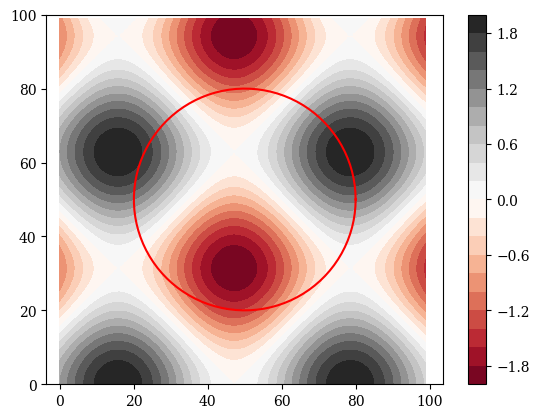

In [28]:
import matplotlib.pyplot as plt

# plot the trajectory with color as height
fig = plt.figure()
plt.plot(x, y, 'r')
plt.contourf(dem_pos[:, :, 0], dem_pos[:, :, 1], dem_pos[:, :, 2], 20, cmap='RdGy')
plt.colorbar()
plt.axis('equal')
plt.xlim([0, 100])
plt.ylim([0, 100])
plt.show()

In [29]:
state, imu_meas = compute_rover_state_kinematics(times, positions, norm_vecs, imu, clock_model)

## Position and Velocity

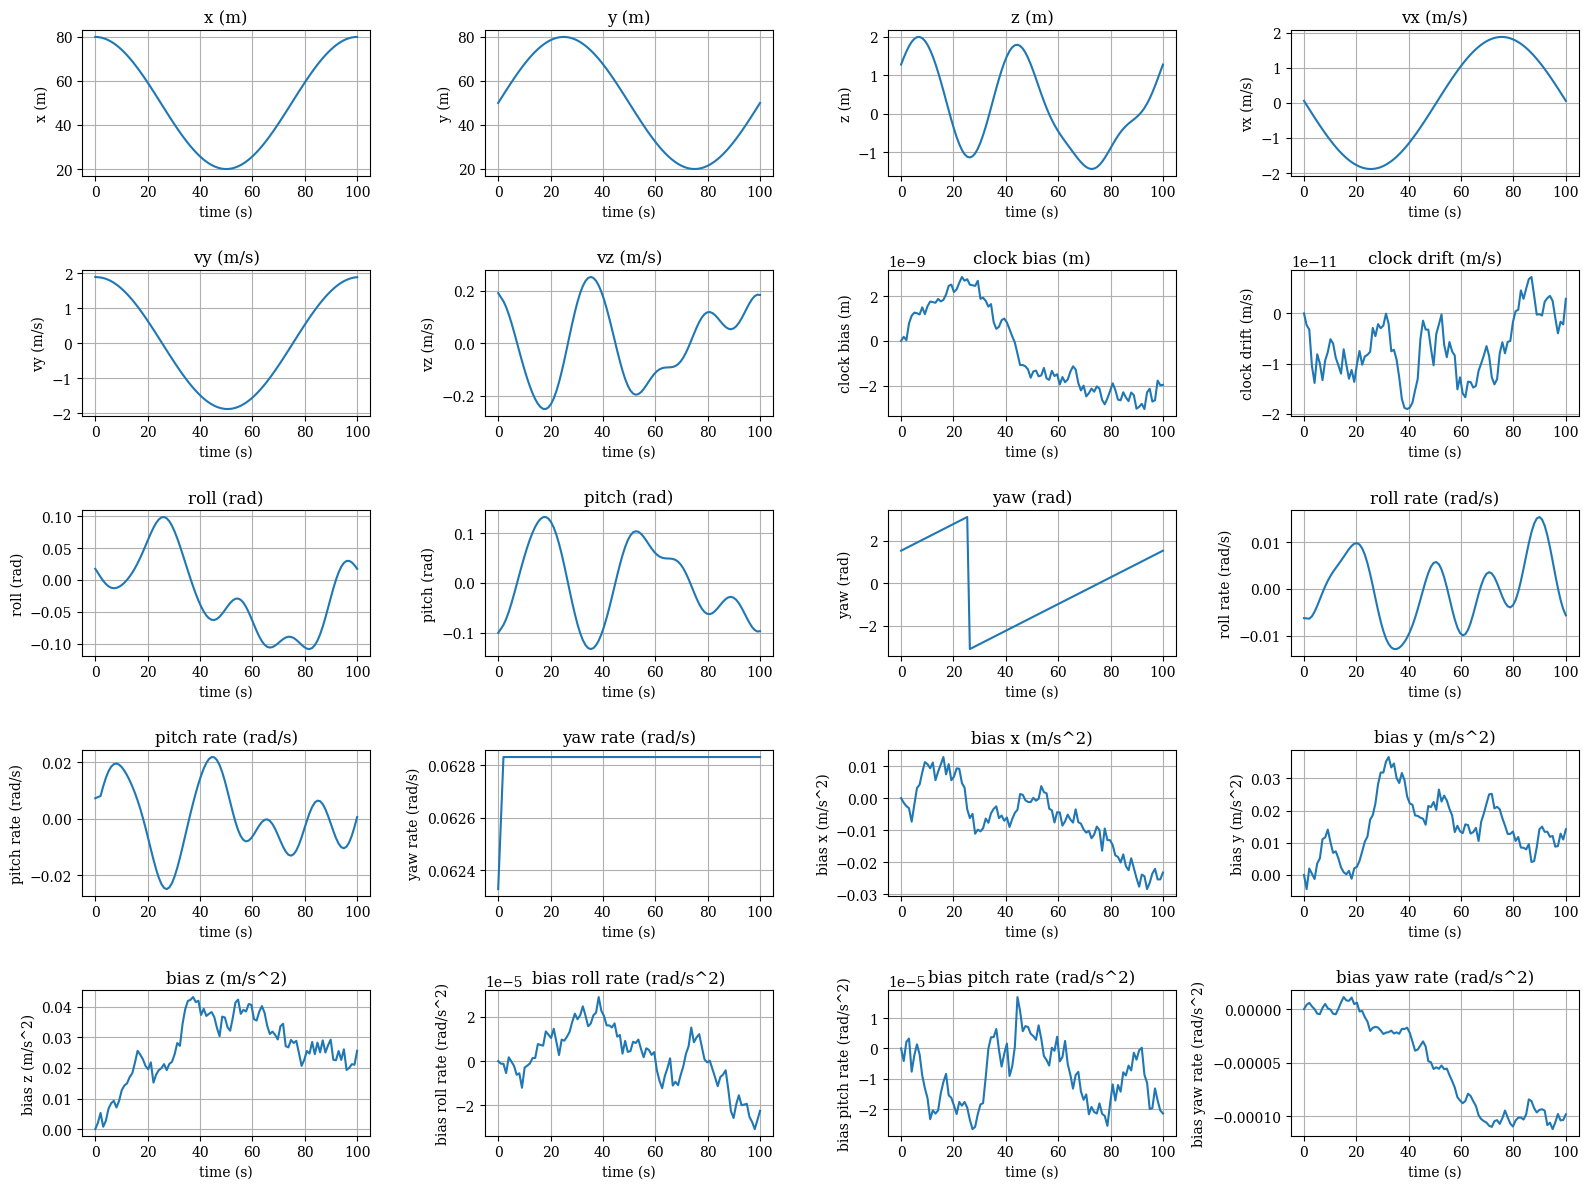

In [30]:
# plot rover position and velocity
fig, axes = plt.subplots(5, 4, figsize=(16, 12))

labels_state = ['x (m)', 'y (m)', 'z (m)', 'vx (m/s)', 'vy (m/s)', 'vz (m/s)', 'clock bias (m)', 'clock drift (m/s)',
          'roll (rad)', 'pitch (rad)', 'yaw (rad)', 'roll rate (rad/s)', 'pitch rate (rad/s)', 'yaw rate (rad/s)',
          'bias x (m/s^2)', 'bias y (m/s^2)', 'bias z (m/s^2)', 'bias roll rate (rad/s^2)', 'bias pitch rate (rad/s^2)', 'bias yaw rate (rad/s^2)']

# position and velocity
for i in range(20):
    ax = axes.flatten()[i]
    ax.plot(times, state[:, i])
    ax.set_title(labels_state[i])
    ax.grid()
    ax.set_xlabel('time (s)')
    ax.set_ylabel(labels_state[i])


plt.tight_layout()
plt.show()

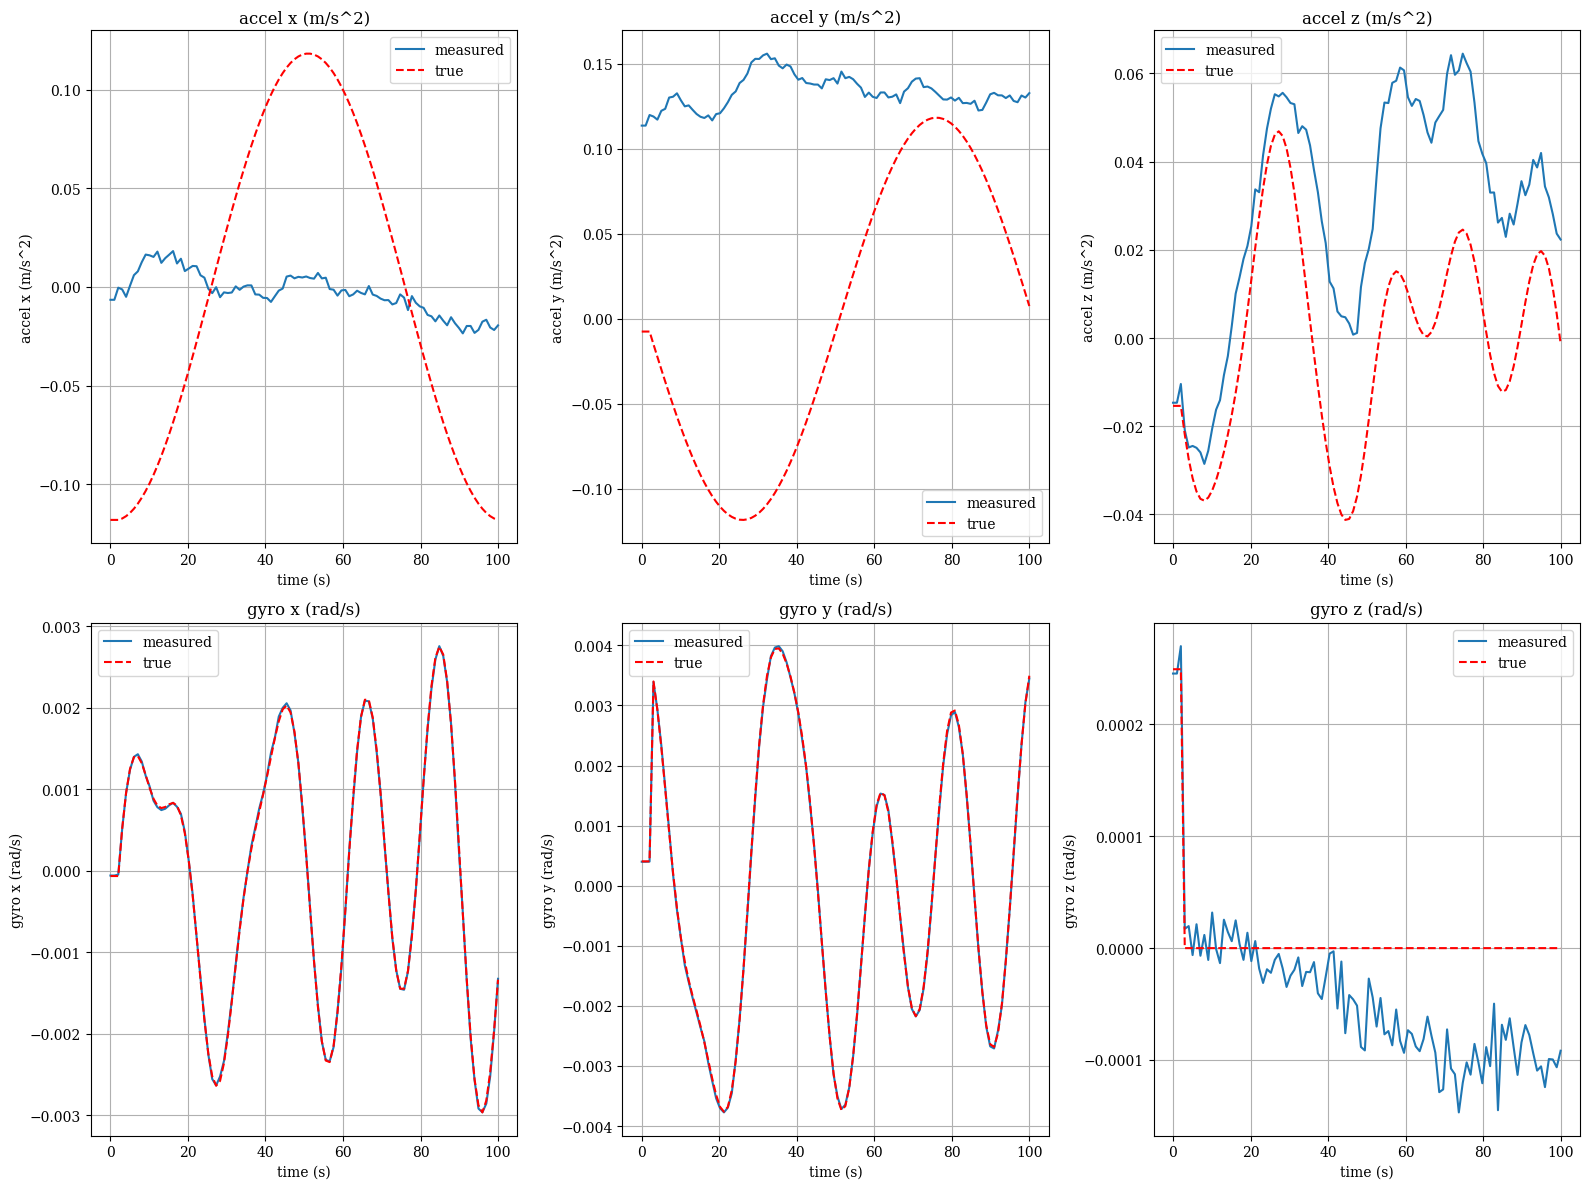

In [31]:
# plot simulated measurements
fig, axes = plt.subplots(2, 3, figsize=(16, 12))

labels = ['accel x (m/s^2)', 'accel y (m/s^2)', 'accel z (m/s^2)', 'gyro roll rate(rad/s)', 'gyro yaw rate (rad/s)', 'gyro pitch rate(rad/s)']

acc_true = np.zeros((len(times), 3))
gyro_true = np.zeros((len(times), 3))

for i in range(1, len(times)):
    acc_true[i] = (state[i, 3:6] - state[i-1, 3:6]) / (times[i] - times[i-1])
    gyro_true[i] = (state[i, 11:14] - state[i-1, 11:14]) / (times[i] - times[i-1])
acc_true[0, :] = acc_true[1, :] - (acc_true[2, :] - acc_true[1, :])
gyro_true[0, :] = gyro_true[1, :] - (gyro_true[2, :] - gyro_true[1, :])

# position and velocity
for i in range(6):
    ax = axes.flatten()[i]
    ax.plot(times, imu_meas[:, i], label='measured')
    ax.plot(times, acc_true[:, i] if i < 3 else gyro_true[:, i-3], 'r--', label='true')
    ax.set_title(labels[i])
    ax.grid()
    ax.set_xlabel('time (s)')
    ax.set_ylabel(labels[i])
    ax.legend()

plt.tight_layout()
plt.show()

## Estimating the Trajectory Only Using IMU Data

(100, 20)
(20, 20)


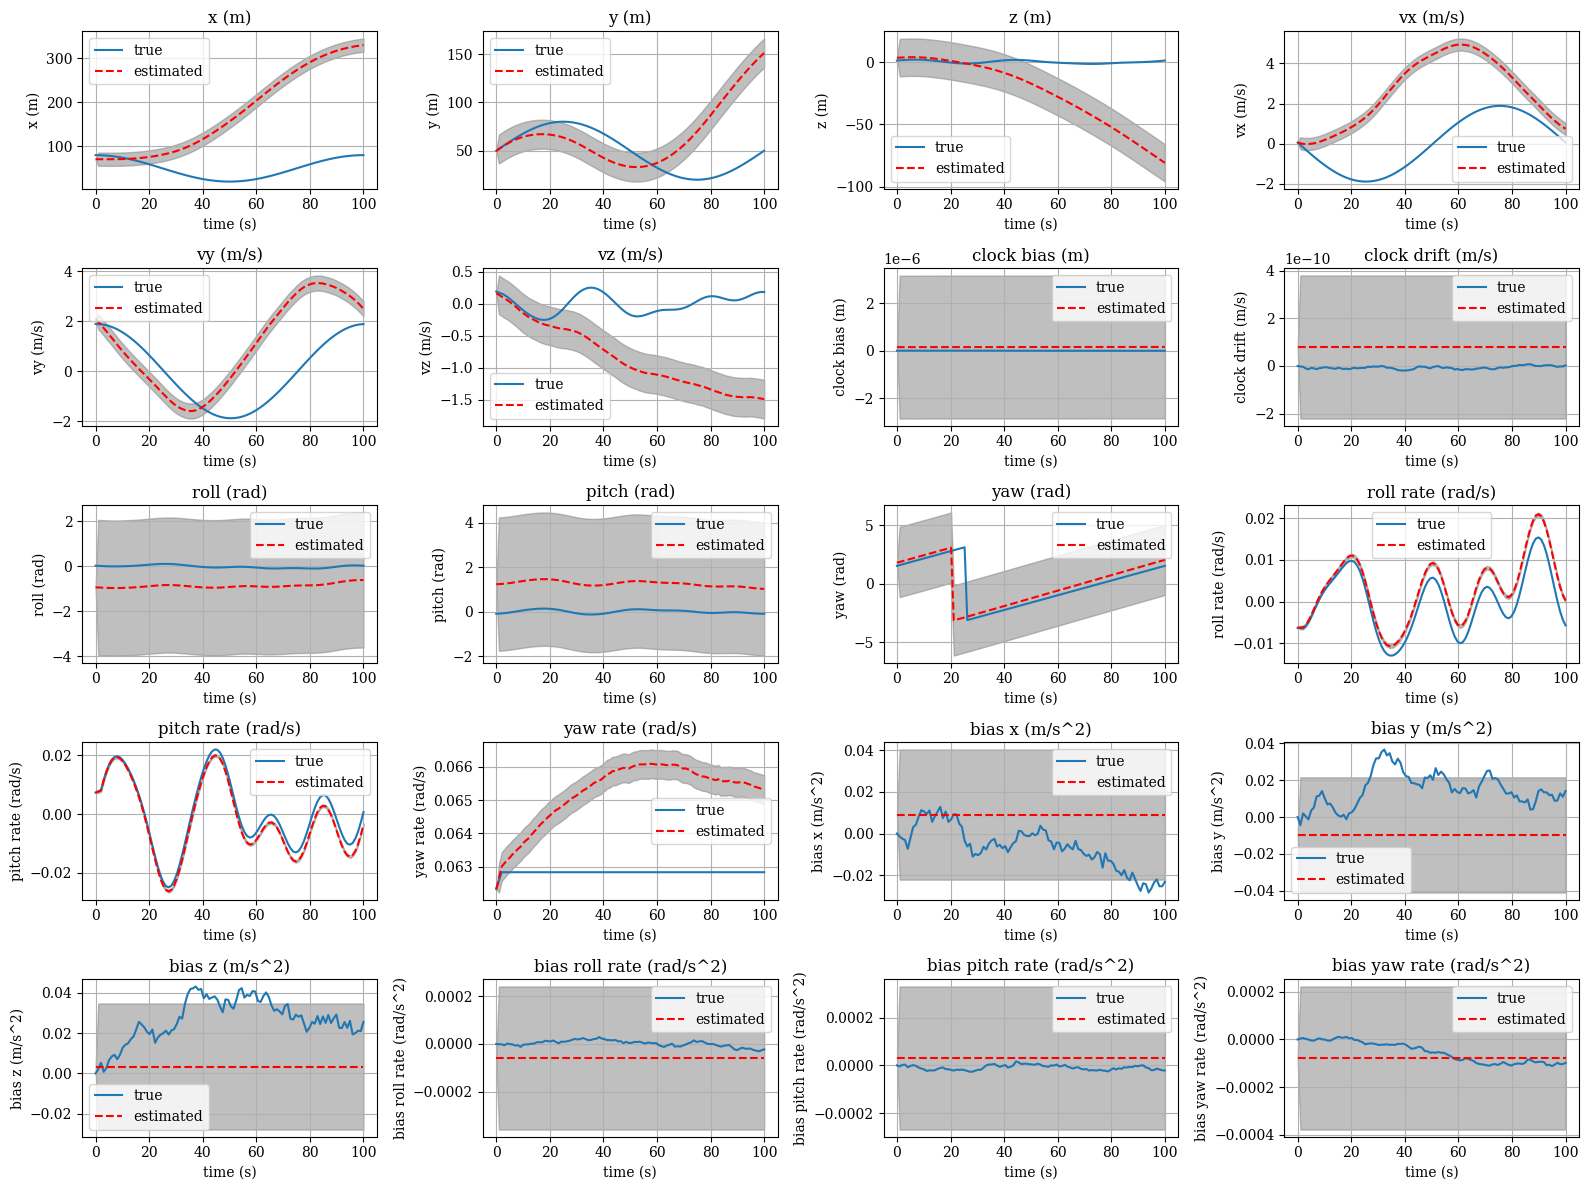

In [32]:
imu_est_traj = np.zeros((len(times), 20))

print(state.shape)

t = 0
init_cov = np.hstack([np.ones(3) * 5,     # position m
                     np.ones(3) * 0.1,   # velocity m/s
                     1e-6,
                     1e-10,   # clock bias and drift s, s/s
                     np.ones(3) * 1,   # euler angles rad
                     np.ones(3) * 1e-4,   # euler rates rad/s
                     np.ones(3) * 1e-2,   # accel bias m/s^2
                     np.ones(3) * 1e-4    # gyro bias rad/s
                     ])
P0 = np.diag(init_cov ** 2)
print(P0.shape)

imu_est_traj[0] = state[0] + np.random.normal(0, init_cov)

sigmas = np.zeros((len(times), 20))
for i in range(1, len(times)):
    dt = times[i] - times[i-1]
    imu_est_traj[i], stm, Q = rover_clock_imu_dynamics(t, imu_est_traj[i-1], imu_meas[i], dt, imu, clock_model)
    P = stm @ P0 @ stm.T + Q
    sigmas[i] = np.sqrt(np.diag(P))
    t += dt

# plot rover position and velocity
fig, axes = plt.subplots(5, 4, figsize=(16, 12))

labels_state = ['x (m)', 'y (m)', 'z (m)', 'vx (m/s)', 'vy (m/s)', 'vz (m/s)', 'clock bias (m)', 'clock drift (m/s)',
          'roll (rad)', 'pitch (rad)', 'yaw (rad)', 'roll rate (rad/s)', 'pitch rate (rad/s)', 'yaw rate (rad/s)',
          'bias x (m/s^2)', 'bias y (m/s^2)', 'bias z (m/s^2)', 'bias roll rate (rad/s^2)', 'bias pitch rate (rad/s^2)', 'bias yaw rate (rad/s^2)']

for i in range(20):
    ax = axes.flatten()[i]
    ax.plot(times, state[:, i], label='true')   
    ax.plot(times, imu_est_traj[:, i], 'r--', label='estimated')
    # color covariance areas
    ax.fill_between(times, imu_est_traj[:, i] - 3 * sigmas[:, i], imu_est_traj[:, i] + 3 * sigmas[:, i], color='gray', alpha=0.5)
    ax.set_title(labels_state[i])
    ax.grid()
    ax.set_xlabel('time (s)')
    ax.set_ylabel(labels_state[i])
    ax.legend()

plt.tight_layout()
plt.show()

## Run a Kalman Filter Update